# CCM-109 - Tópicos especiais de IA - Deep Learning

## Pipeline de detecção de deepfake

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jtlimo/ccm-109/blob/main/prediction.ipynb)

---

### Índice

1. [Configuração](#1-configuração)
2. [Dataset FF++](#2-dataset-faceforensics)
3. [Funções auxiliares](#3-funções-auxiliares)
4. [Treino](#4-treino)

## 1.Configuração

In [ ]:
# %pip install --upgrade pip
%pip install -q tensorflow scikit-learn keras-hub

In [14]:
# @title Configurações

import os
import glob
import keras_hub
import preprocess as pi
from pathlib import Path
import numpy as np
import cv2
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import preprocess as pi
import grad_cam as gc
import config as cfg

cfg.choice_config()

CONFIGURAÇÕES


Dropdown(description='Dataset:', index=1, layout=Layout(width='400px'), options=('Celeb-DF', 'Custom', 'FF++')…

FloatSlider(value=0.5, description='Threshold:', layout=Layout(width='400px'), max=0.9, min=0.1, step=0.05, st…

IntSlider(value=32, description='Batch size:', layout=Layout(width='400px'), max=128, min=8, step=8, style=Sli…

Dropdown(description='Agregação:', layout=Layout(width='400px'), options=('median', 'mean', 'max', 'trimmed_me…

IntSlider(value=10, description='Trim %:', layout=Layout(width='400px'), max=50, step=5, style=SliderStyle(des…

In [15]:
# @title Desativar GPU

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # Desativa GPU

import tensorflow as tf
from tensorflow import keras

AUTOTUNE = tf.data.AUTOTUNE

print(f"GPUs visíveis: {tf.config.list_physical_devices('GPU')}")
print(f'TensorFlow: {tf.__version__}')

GPUs visíveis: []
TensorFlow: 2.20.0


## 2. Funções auxiliares

In [16]:
CFG = cfg.get_config()

print("\n" + "=" * 60)
print("CFG ATUAL:")
print("=" * 60)
for k, v in CFG.items():
    print(f"  {k:20s}: {v}")


CFG ATUAL:
  dataset             : Celeb-DF
  threshold           : 0.5
  batch_size          : 32
  aggregation         : median
  trim_percent        : 10
  img_size            : 224
  confidence          : 0.9
  min_face_size       : 80
  skip_frames         : 9
  max_frames          : 30
  max_read_limit      : 1000
  jpg_quality         : 95
  video_extensions    : ('*.mp4', '*.avi', '*.mov', '*.mkv', '*.webm')
  siglip_mean         : [0.5 0.5 0.5]
  siglip_std          : [0.5 0.5 0.5]
  dataset_path        : /dataset/Celeb-DF
  pred_output_dir     : /dataset/Celeb-DF/predictions
  frames_output_dir   : /dataset/Celeb-DF/frames
  fake_dir            : /dataset/Celeb-DF/fake
  real_dir            : /dataset/Celeb-DF/real


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
)

translated_names = {
    "TPR": r"Revocação (TPR)",
    "FPR": r"Falsos Positivos (FPR)",
    "TNR": r"Especificidade (TNR)",
    "ERR": r"Taxa de Erro (ERR)",
    "ACC": r"Acurácia Global (ACC)",
    "F1": r"F1-Score",
    "MCC": r"Coeficiente MCC",
    "PMD": r"Probabilidade de Falha (PMD)"
}

def get_weighted_metrics(y_true_or_dict, y_pred=None, threshold=0.5):
    if isinstance(y_true_or_dict, dict):
        y_true = y_true_or_dict["y_true"]
        probs = y_true_or_dict["y_pred_prob"]
        y_pred = (probs >= threshold).astype(int)
    else:
        y_true = y_true_or_dict

    if y_pred is None:
        raise ValueError(
            "O parâmetro 'y_pred' é obrigatório quando 'y_true_or_dict' não for um dicionário."
        )
    
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    tpr = recall_score(
        y_true, y_pred, average="weighted", zero_division=0
    ) 
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    err = 1.0 - acc

    rec_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)
    _, counts = np.unique(y_true, return_counts=True)
    weights = counts / len(y_true)

    tnr = (
        np.sum(rec_per_class[::-1] * weights)
        if len(rec_per_class) > 1
        else rec_per_class[0]
    )
    fpr = 1.0 - tnr
    pmd = 1.0 - tpr

    return {
        "TPR": tpr,
        "FPR": fpr,
        "TNR": tnr,
        "ERR": err,
        "ACC": acc,
        "F1": f1,
        "MCC": mcc,
        "PMD": pmd,
    }



def print_weighted_metrics(metrics_weighted):
    data = [(translated_names.get(k, k), v) for k, v in metrics_weighted.items()]
    df = pd.DataFrame(data, columns=["Métrica", "Valor"])
    df["Valor"] = df["Valor"].map(lambda x: f"{x:.4f}")
    return df.style.hide(axis='index')


def plot_metrics_graphic(results, metrics_to_plot, title, save_pdf=True):
    mpl.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 11
    })
    
    algorithms = list(results.keys())
    first_metric_val = [results[alg][metrics_to_plot[0]] * 100 for alg in algorithms] 
    second_metric_val = [results[alg][metrics_to_plot[1]] * 100 for alg in algorithms] 

    x = np.arange(len(algorithms))
    width = 0.25
    gap = 0.04

    fig, ax = plt.subplots(figsize=(6, 4.5))

    rects1 = ax.bar(x - width/2 - gap/2, first_metric_val, width, 
                   label=translated_names.get(metrics_to_plot[0].upper(), metrics_to_plot[0].upper()), 
                   color='#2563eb', edgecolor='black', linewidth=0.8)
                   
    rects2 = ax.bar(x + width/2 + gap/2, second_metric_val, width, 
                   label=translated_names.get(metrics_to_plot[1].upper(), metrics_to_plot[1].upper()), 
                   color='#94a3b8', edgecolor='black', linewidth=0.8)

    ax.bar_label(rects1, fmt='%.1f%%', padding=3, fontsize=9)
    ax.bar_label(rects2, fmt='%.1f%%', padding=3, fontsize=9)

    ax.set_ylabel(r'Desempenho (\%)', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(algorithms, fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=10)
    ax.set_ylim(0, 115)
    
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

    plt.tight_layout()
    if save_pdf:
        filename = f"{title.lower().replace(' ', '_')}.pdf"
        plt.savefig(filename, bbox_inches="tight", pad_inches=0.1)
        print(f"📊 Gráfico vetorial salvo com sucesso: {filename}")
    plt.show()

## Métricas

In [ ]:
#@title métricas para o modelo temporal (evaluation)

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve,
    ConfusionMatrixDisplay,
    classification_report
)

def get_ground_truth_label(v_path, true_labels_dict):
    v_path = Path(v_path)
    v_name = v_path.stem
    
    if v_name in true_labels_dict:
        return true_labels_dict[v_name]
    
    for part in reversed(v_path.parts[:-1]):
        p = part.lower()
        if p in ["real", "celeb-real", "youtube-real"] or p.endswith("_real"):
            return 0
        if p in ["fake", "celeb-synthesis", "synthesis"] or "fake" in p or "synth" in p:
            if p not in ["deepfake", "deepfakes", "fake_detection", "predictions"]:
                return 1
                
    return None

def evaluate_custom_dataset_temporal(
    temporal_model,
    detector_or_backbone,
    video_paths,
    true_labels_dict=None,
    cfg=None,
    threshold=0.5,
    sequence_length=30
):
    cfg = cfg or CFG
    true_labels_dict = true_labels_dict or {}
    
    print(f"🔍 Avaliando {len(video_paths)} vídeos no dataset {cfg["dataset_path"]} com o modelo temporal...")
    
    backbone = getattr(detector_or_backbone, "backbone", detector_or_backbone)
    
    y_true = []
    y_pred_prob = []
    errors = []
    processed_count = 0

    for idx, v_path in enumerate(video_paths):
        v_path = Path(v_path)
        v_name = v_path.stem
        
        label = get_ground_truth_label(v_path, true_labels_dict)
        if label is None:
            errors.append({"video": v_name, "error": "Sem ground truth identificável"})
            continue

        pipeline = preprocess_video_for_prediction(v_path, cfg["pred_output_dir"])
        if pipeline["tensor"] is None or len(pipeline["tensor"]) == 0:
            errors.append({"video": v_name, "error": "Nenhuma face detectada"})
            continue
        
        frames = pipeline["tensor"] 

        embeddings = backbone.get_vision_embeddings(frames)
        seq_input = prepare_single_video_sequence(embeddings.numpy(), sequence_length=sequence_length)

        score = float(temporal_model.predict(seq_input, verbose=0)[0, 0])

        y_true.append(label)
        y_pred_prob.append(score)
        processed_count += 1
        
        if (idx + 1) % 10 == 0 or (idx + 1) == len(video_paths):
            print(f"  • Processados: {idx + 1}/{len(video_paths)} vídeos...")

    y_true = np.array(y_true)
    y_pred_prob = np.array(y_pred_prob)
    y_pred_bin = (y_pred_prob >= threshold).astype(int)

    if len(y_true) == 0:
        print("⚠️ Nenhum vídeo válido foi avaliado.")
        return {"errors": errors}

    acc = accuracy_score(y_true, y_pred_bin)
    has_both_classes = len(np.unique(y_true)) > 1
    auc = roc_auc_score(y_true, y_pred_prob) if has_both_classes else 0.0
    f1 = f1_score(y_true, y_pred_bin, zero_division=0)
    prec = precision_score(y_true, y_pred_bin, zero_division=0)
    rec = recall_score(y_true, y_pred_bin, zero_division=0)

    print("\n" + "=" * 60)
    print("📊 RELATÓRIO DE AVALIAÇÃO TEMPORAL - DATASET CUSTOMIZADO")
    print("=" * 60)
    print(f" • Vídeos Avaliados:     {len(y_true)} / {len(video_paths)}")
    print(f" • Descartados/Erros:    {len(errors)}")
    print(f" • Acurácia Global:      {acc * 100:.2f}%")
    if has_both_classes:
        print(f" • AUC-ROC:              {auc:.4f}")
    print(f" • F1-Score (Fake):      {f1:.4f}")
    print(f" • Precisão (Fake):      {prec:.4f}")
    print(f" • Revocação / Recall:   {rec:.4f}")
    print("=" * 60)

    print("\n--- Detalhamento Completo por Classe ---")
    print(classification_report(y_true, y_pred_bin, target_names=["Real (0)", "Fake (1)"], digits=4))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(y_true, y_pred_bin)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real (0)", "Fake (1)"])
    disp.plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
    axes[0].set_title("Matriz de Confusão (Nível de Vídeo)", fontsize=12, fontweight="bold")
    axes[0].grid(False)

    if has_both_classes:
        fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
        axes[1].plot(fpr, tpr, color="#2563eb", lw=2, label=f"BiGRU Temporal (AUC = {auc:.4f})")
        axes[1].plot([0, 1], [0, 1], color="#9ca3af", lw=1.5, linestyle="--", label="Acaso (AUC = 0.5000)")
        axes[1].set_xlabel("Taxa de Falsos Positivos (FPR)", fontsize=10)
        axes[1].set_ylabel("Taxa de Verdadeiros Positivos (TPR)", fontsize=10)
        axes[1].set_title("Curva ROC (Nível de Vídeo)", fontsize=12, fontweight="bold")
        axes[1].legend(loc="lower right")
        axes[1].grid(True, linestyle=":", alpha=0.6)
    else:
        axes[1].text(0.5, 0.5, "Apenas 1 classe presente no dataset", ha="center", va="center")
        axes[1].set_title("Curva ROC Indisponível")

    plt.tight_layout()
    plt.show()

    return {
        "y_true": y_true,
        "y_pred_prob": y_pred_prob,
        "accuracy": acc,
        "auc_roc": auc,
        "f1_score": f1,
        "confusion_matrix": cm,
        "errors": errors
    }

In [36]:
#@title métricas para o modelo frame a frame (evaluation)
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve,
    ConfusionMatrixDisplay,
    classification_report
)

def evaluate_custom_dataset_frame_level(
    frame_model,
    video_paths,
    true_labels_dict=None,
    cfg=None,
    threshold=0.5,
    aggregation="median"
):
    cfg = cfg or CFG
    true_labels_dict = true_labels_dict or {}
    dataset_name = cfg.get("dataset_path", "Custom")
    
    print(f"🔍 Avaliando {len(video_paths)} vídeos no dataset {dataset_name} (Frame-Level - Agregação: '{aggregation}')...")
    
    y_true = []
    y_pred_prob = []
    errors = []

    for idx, v_path in enumerate(video_paths):
        v_path = Path(v_path)
        v_name = v_path.stem
        
        label = get_ground_truth_label(v_path, true_labels_dict)
        if label is None:
            errors.append({"video": v_name, "error": "Sem ground truth identificável"})
            continue

        pipeline = preprocess_video_for_prediction(v_path, cfg["pred_output_dir"])
        if pipeline["tensor"] is None or len(pipeline["tensor"]) == 0:
            errors.append({"video": v_name, "error": "Nenhuma face detectada"})
            continue
        
        frames = pipeline["tensor"]

        if hasattr(frame_model, "predict"):
            frame_probs = frame_model.predict(frames, verbose=0).flatten()
        else:
            frame_probs = frame_model(frames, training=False).numpy().flatten()

        video_score = aggregate_video(frame_probs, aggregation)

        y_true.append(label)
        y_pred_prob.append(video_score)
        
        if (idx + 1) % 10 == 0 or (idx + 1) == len(video_paths):
            print(f"  • Processados: {idx + 1}/{len(video_paths)} vídeos...")

    y_true = np.array(y_true)
    y_pred_prob = np.array(y_pred_prob)
    y_pred_bin = (y_pred_prob >= threshold).astype(int)

    if len(y_true) == 0:
        print("⚠️ Nenhum vídeo válido foi avaliado.")
        return {"errors": errors}

    acc = accuracy_score(y_true, y_pred_bin)
    has_both_classes = len(np.unique(y_true)) > 1
    auc = roc_auc_score(y_true, y_pred_prob) if has_both_classes else 0.0
    f1 = f1_score(y_true, y_pred_bin, zero_division=0)
    prec = precision_score(y_true, y_pred_bin, zero_division=0)
    rec = recall_score(y_true, y_pred_bin, zero_division=0)

    print("\n" + "=" * 60)
    print(f"📊 RELATÓRIO DE AVALIAÇÃO FRAME-LEVEL ({aggregation.upper()})")
    print("=" * 60)
    print(f" • Vídeos Avaliados:     {len(y_true)} / {len(video_paths)}")
    print(f" • Descartados/Erros:    {len(errors)}")
    print(f" • Acurácia Global:      {acc * 100:.2f}%")
    if has_both_classes:
        print(f" • AUC-ROC:              {auc:.4f}")
    print(f" • F1-Score (Fake):      {f1:.4f}")
    print(f" • Precisão (Fake):      {prec:.4f}")
    print(f" • Revocação / Recall:   {rec:.4f}")
    print("=" * 60)

    print("\n--- Detalhamento Completo por Classe ---")
    print(classification_report(y_true, y_pred_bin, target_names=["Real (0)", "Fake (1)"], digits=4))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(y_true, y_pred_bin)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real (0)", "Fake (1)"])
    disp.plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
    axes[0].set_title("Matriz de Confusão (Nível de Vídeo)", fontsize=12, fontweight="bold")
    axes[0].grid(False)

    if has_both_classes:
        fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
        axes[1].plot(fpr, tpr, color="#2563eb", lw=2, label=f"Frame-Level {aggregation.capitalize()} (AUC = {auc:.4f})")
        axes[1].plot([0, 1], [0, 1], color="#9ca3af", lw=1.5, linestyle="--", label="Acaso (AUC = 0.5000)")
        axes[1].set_xlabel("Taxa de Falsos Positivos (FPR)", fontsize=10)
        axes[1].set_ylabel("Taxa de Verdadeiros Positivos (TPR)", fontsize=10)
        axes[1].set_title("Curva ROC (Nível de Vídeo)", fontsize=12, fontweight="bold")
        axes[1].legend(loc="lower right")
        axes[1].grid(True, linestyle=":", alpha=0.6)
    else:
        axes[1].text(0.5, 0.5, "Apenas 1 classe presente no dataset", ha="center", va="center")
        axes[1].set_title("Curva ROC Indisponível")

    plt.tight_layout()
    plt.show()

    return {
        "y_true": y_true,
        "y_pred_prob": y_pred_prob,
        "accuracy": acc,
        "auc_roc": auc,
        "f1_score": f1,
        "confusion_matrix": cm,
        "errors": errors
    }

In [37]:
# @title Métricas agregadoras

def aggregate_mean(preds):
    return float(np.mean(preds))


def aggregate_median(preds):
    return float(np.median(preds))


def aggregate_vote(preds, threshold=0.5):
    return float(np.mean(preds > threshold))


def aggregate_trimmed_mean(preds, trim_percent=10):
    lower = np.percentile(preds, trim_percent)
    upper = np.percentile(preds, 100 - trim_percent)
    trimmed = preds[(preds >= lower) & (preds <= upper)]
    return float(np.mean(trimmed))


def aggregate_video(preds, method="median", threshold=0.5, trim_percent=10):
    if method == "mean":
        return aggregate_mean(preds)
    elif method == "median":
        return aggregate_median(preds)
    elif method == "vote":
        return aggregate_vote(preds, threshold)
    elif method == "trimmed_mean":
        return aggregate_trimmed_mean(preds, trim_percent)
    else:
        raise ValueError(f"Método desconhecido: {method}")


def classify_video(video_score, threshold=0.5):
    return "fake" if video_score > threshold else "real"

## 3. Pré-processamento

In [19]:
# @title Pre-processamento de video para predição

FEATURES_CACHE = os.path.join(CFG['dataset_path'], "siglip2_features.npz")

def load_preprocessed_frames(video_name, frames_dir, img_size=224):
    frame_dir = Path(frames_dir) / video_name
    jpg_files = sorted(frame_dir.glob("*.jpg"))
    
    if not jpg_files:
        return None
    
    frames = []
    for f in jpg_files:
        img = cv2.imread(str(f))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        normalized = pi.normalize_siglip2(img)
        frames.append(normalized)
    
    return np.stack(frames, axis=0)


def preprocess_video_for_prediction(video_path, output_dir=None):
    output_dir = output_dir or CFG["pred_output_dir"]
    video_path = Path(video_path)
    video_name = video_path.stem

    n_faces = pi.process_video(video_path, output_dir)

    if n_faces == 0:
        print(f"[AVISO] Nenhuma face detectada em {video_path.name}")
        return {"tensor": None, "frame_paths": [], "video_name": video_name}

    frames = load_preprocessed_frames(video_name, output_dir)
    video_dir = Path(output_dir) / video_name
    frame_paths = sorted(video_dir.glob("*.jpg"))


    if frames is None or len(frames) == 0:
         return {"tensor": None, "frame_paths": [], "video_name": video_name}

    return {
        "tensor": frames,
        "frame_paths": [str(p) for p in frame_paths],
        "video_name": video_name,
        "n_frames": len(frames)
    }


def prepare_single_video_sequence(embeddings, sequence_length=30):
    n_frames = len(embeddings)
    if n_frames >= sequence_length:
        indices = np.linspace(0, n_frames - 1, sequence_length, dtype=int)
        seq = embeddings[indices]
    else:
        padding_shape = (sequence_length - n_frames, embeddings.shape[1])
        padding = np.zeros(padding_shape, dtype=embeddings.dtype)
        seq = np.vstack([embeddings, padding])
        
    return np.expand_dims(seq, axis=0)

## 4. Predição

In [20]:
def predict_video(model, video_path, output_dir=None, cfg=None, is_temporal=False, frame_detector=None):
    cfg = cfg or CFG
    pipeline = preprocess_video_for_prediction(video_path, output_dir)

    if pipeline["tensor"] is None:
        return {
            "video_path": str(video_path),
            "video_name": pipeline["video_name"],
            "error": "Nenhuma face detectada",
            "frame_probs": np.array([]),
            "video_score": None,
            "video_label": None,
            "n_frames": 0
        }

    frames = pipeline["tensor"]

    if is_temporal and frame_detector is not None:
        embeddings = frame_detector.backbone.get_vision_embeddings(frames)
        seq_input = prepare_single_video_sequence(embeddings.numpy(), sequence_length=30)

        video_score = float(model.predict(seq_input, verbose=1)[0,0])

        if frame_detector is not None:
            frame_probs = frame_detector.model.predict(frames, batch_size=cfg["batch_size"], verbose=1)\
            .flatten()
        else:
            frame_probs = np.full(len(frames), video_score)
    else:
        frame_probs = model.model.predict(frames, batch_size=cfg["batch_size"], verbose=1).flatten()
   
        video_score = aggregate_video(
            frame_probs,
            method=cfg["aggregation"],
            threshold=cfg["threshold"],
            trim_percent=cfg["trim_percent"]
        )

    video_label = classify_video(video_score, cfg["threshold"])

    
    return {
        "video_path": str(video_path),
        "video_name": pipeline["video_name"],
        "frame_paths": pipeline["frame_paths"],
        "frame_probs": frame_probs,
        "video_score": video_score,
        "video_label": video_label,
        "n_frames": len(frame_probs),
        "tensor": frames,
    }

In [21]:
# @title Predição de vídeos
import grad_cam as gc

def predict_and_explain_video(detector, video_path, out_dir, n_explain_frames=6, cfg=None, is_temporal=False, frame_detector=None):
    cfg = cfg or CFG
    
    result = predict_video(detector, video_path, out_dir, cfg, is_temporal, frame_detector)
    
    if result.get("error"):
        return result
    
    print(f"\n[RESULTADO] Score: {result['video_score']:.4f} | Label: {result['video_label'].upper()}")
    
    plot_video_prediction(result)
    
    frame_probs = result["frame_probs"]
    n_frames = len(frame_probs)
    
    if n_frames == 0:
        print("[AVISO] Nenhum frame para explicar.")
        return result
    
    if result["video_label"] == "fake":
        top_indices = np.argsort(frame_probs)[-n_explain_frames:][::-1]
    else:
        top_indices = np.argsort(frame_probs)[:n_explain_frames]

    top_indices = [int(i) for i in top_indices]
    print(f"[EXPLICAÇÃO] Analisando {len(top_indices)} frames: {list(top_indices)}")
    
    frames = result["tensor"]
    selected_frames = [frames[i] for i in top_indices]
    
    explanations = []
    for idx in top_indices:
        frame = frames[idx]
        
        exp = gc.explain_video_frame(detector, frame, is_temporal, frame_detector)
        exp["frame_idx"] = int(idx)
        exp["frame_prob"] = float(frame_probs[idx])
        explanations.append(exp)

    fig = gc.plot_gradcam_explanations(
        selected_frames, 
        explanations, 
        video_label=result["video_label"], 
        figsize=(20, 8)
    )
    
    return {**result, "explanations": explanations, "fig": fig}

In [22]:
# @title Avaliação do modelo

def evaluate_predictions(results, true_labels_dict):
    y_true = []
    y_pred = []
    y_scores = []
    errors = []

    for res in results:
        name = res["video_name"]

        if res.get("error"):
            errors.append({"video": name, "error": res["error"]})
            continue

        if name not in true_labels_dict:
            errors.append({"video": name, "error": "Sem ground truth"})
            continue

        y_true.append(true_labels_dict[name])
        y_pred.append(1 if res["video_label"] == "fake" else 0)
        y_scores.append(res["video_score"])

    metrics = {
        "n_evaluated": len(y_true),
        "n_errors": len(errors),
        "accuracy": accuracy_score(y_true, y_pred) if y_true else None,
        "f1": f1_score(y_true, y_pred) if y_true else None,
    }

    if len(set(y_true)) > 1:
        metrics["auc"] = roc_auc_score(y_true, y_scores)

    return {"metrics": metrics, "errors": errors, "details": list(zip(y_true, y_pred, y_scores))}



In [23]:
# @title Visualização de resultados

def plot_video_prediction(result, cfg=None, figsize=(14, 4)):
    cfg = cfg or CFG

    if result.get("error"):
        print(f"Erro: {result['error']}")
        return

    probs = result["frame_probs"]
    n = len(probs)

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    colors = ["#dc2626" if p > cfg["threshold"] else "#16a34a" for p in probs]
    axes[0].bar(range(n), probs, color=colors, alpha=0.85, edgecolor="white", linewidth=0.5)
    axes[0].axhline(y=cfg["threshold"], color="#f59e0b", linestyle="--", linewidth=2, label=f"threshold={cfg['threshold']}")
    axes[0].axhline(y=result["video_score"], color="#3b82f6", linestyle="-", linewidth=2.5, label=f"{cfg['aggregation']}={result['video_score']:.3f}")
    axes[0].set_xlabel("Frame")
    axes[0].set_ylabel("Probabilidade FAKE")
    axes[0].set_title(f"Predições por Frame | {result['video_label'].upper()}")
    axes[0].legend(fontsize=9)
    axes[0].set_ylim(0, 1)

    axes[1].hist(probs, bins=min(20, n), color="#6366f1", alpha=0.7, edgecolor="white")
    axes[1].axvline(x=result["video_score"], color="#3b82f6", linestyle="-", linewidth=2.5)
    axes[1].axvline(x=cfg["threshold"], color="#f59e0b", linestyle="--", linewidth=2)
    axes[1].set_xlabel("Probabilidade FAKE")
    axes[1].set_ylabel("Frequência")
    axes[1].set_title("Distribuição")

    axes[2].plot(range(n), probs, color="#8b5cf6", linewidth=1.5, alpha=0.8)
    axes[2].axhline(y=cfg["threshold"], color="#f59e0b", linestyle="--", linewidth=2)
    axes[2].axhline(y=result["video_score"], color="#3b82f6", linestyle="-", linewidth=2.5)
    axes[2].fill_between(range(n), 0, probs, where=(probs > cfg["threshold"]), alpha=0.2, color="#dc2626")
    axes[2].fill_between(range(n), 0, probs, where=(probs <= cfg["threshold"]), alpha=0.2, color="#16a34a")
    axes[2].set_xlabel("Frame (tempo)")
    axes[2].set_ylabel("Probabilidade FAKE")
    axes[2].set_title("Evolução Temporal")
    axes[2].set_ylim(0, 1)

    fig.suptitle(f"{result['video_name']} | Frames: {n}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_aggregation_comparison(probs, threshold=0.5, trim_percent=10):
    methods = ["mean", "median", "vote", "trimmed_mean"]
    scores = [aggregate_video(probs, m, threshold, trim_percent) for m in methods]
    labels = [classify_video(s, threshold) for s in scores]
    colors = ["#dc2626" if l == "fake" else "#16a34a" for l in labels]

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(methods, scores, color=colors, alpha=0.85, edgecolor="white", linewidth=2)

    ax.axhline(y=threshold, color="#f59e0b", linestyle="--", linewidth=2)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score Agregado")
    ax.set_title("Comparação de Métodos de Agregação", pad=20)

    for bar, score, label in zip(bars, scores, labels):
        y_pos = score - 0.08 if score > 0.85 else score + 0.03
        va_align = "top" if score > 0.85 else "bottom"
        color_text = "white" if score > 0.85 else "black"


        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f"{score:.3f}\n({label.upper()})", ha="center", va=va_align,
                fontsize=11, fontweight="bold", color= color_text)

    plt.tight_layout()
    plt.show()


def plot_dataset_results(results, cfg=None, figsize=(12, 6)):
    cfg = cfg or CFG
    valid = [r for r in results if not r.get("error")]
    if not valid:
        print("Nenhum resultado válido.")
        return

    names = [r["video_name"][:22] for r in valid]
    scores = [r["video_score"] for r in valid]
    labels = [r["video_label"] for r in valid]
    colors = ["#dc2626" if l == "fake" else "#16a34a" for l in labels]

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(range(len(names)), scores, color=colors, alpha=0.85, edgecolor="white")
    ax.axvline(x=cfg["threshold"], color="#f59e0b", linestyle="--", linewidth=2)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel("Score Agregado")
    ax.set_title(f"Resultados por Vídeo | Agregação: {cfg['aggregation']}")
    ax.set_xlim(0, 1)
    ax.invert_yaxis()

    for bar, score in zip(bars, scores):
        ax.text(score + 0.02, bar.get_y() + bar.get_height()/2, f"{score:.3f}",
                va="center", fontsize=9, fontweight="bold")

    plt.tight_layout()
    plt.show()

## 5. Execução da pipeline

In [30]:
# @title Videos encontrados
os.makedirs(CFG['pred_output_dir'], exist_ok=True)

video_dir = CFG['dataset_path']
print(f"Procurando vídeos em: {video_dir}")

video_paths = sorted(glob.glob(os.path.join(video_dir, '**/*.mp4'), recursive=True))
print(f"✓ Vídeos encontrados: {len(video_paths)}")

Procurando vídeos em: /dataset/Celeb-DF
✓ Vídeos encontrados: 400


In [31]:
# Validação rápida de leitura dos rótulos
sample_labels = [get_ground_truth_label(p, {}) for p in video_paths]
print(f"Contagem detectada -> Reais (0): {sample_labels.count(0)} | Fakes (1): {sample_labels.count(1)}")

Contagem detectada -> Reais (0): 200 | Fakes (1): 200


In [32]:
# @title Carregar modelo E2E
import model as m

backbone_path = "siglip2_base_patch16_224_original_backbone.keras"


if not os.path.exists(backbone_path):
    print(f"⚠️  Backbone não encontrado, baixando...")
    backbone = keras_hub.models.SigLIPBackbone.from_preset("siglip2_base_patch16_224")
    backbone.trainable = False
    backbone.save(backbone_path)

### 5.1 Modelo temporal

[INFO] Carregando Backbone de: siglip2_base_patch16_224_original_backbone.keras
[INFO] Carregando Classifier de: best_frame_model.keras
[OK] Modelo End-to-End congelado (93,114,309 parâmetros).
🔍 Avaliando 400 vídeos no dataset /dataset/Celeb-DF com o modelo temporal...
  • Processados: 10/400 vídeos...
  • Processados: 20/400 vídeos...
  • Processados: 30/400 vídeos...
  • Processados: 40/400 vídeos...
  • Processados: 50/400 vídeos...
  • Processados: 60/400 vídeos...
  • Processados: 70/400 vídeos...
  • Processados: 80/400 vídeos...
  • Processados: 90/400 vídeos...
  • Processados: 100/400 vídeos...
  • Processados: 110/400 vídeos...
  • Processados: 120/400 vídeos...
  • Processados: 130/400 vídeos...
  • Processados: 140/400 vídeos...
  • Processados: 150/400 vídeos...
  • Processados: 160/400 vídeos...
  • Processados: 170/400 vídeos...
  • Processados: 180/400 vídeos...
  • Processados: 190/400 vídeos...
  • Processados: 200/400 vídeos...
  • Processados: 210/400 vídeos...
  •

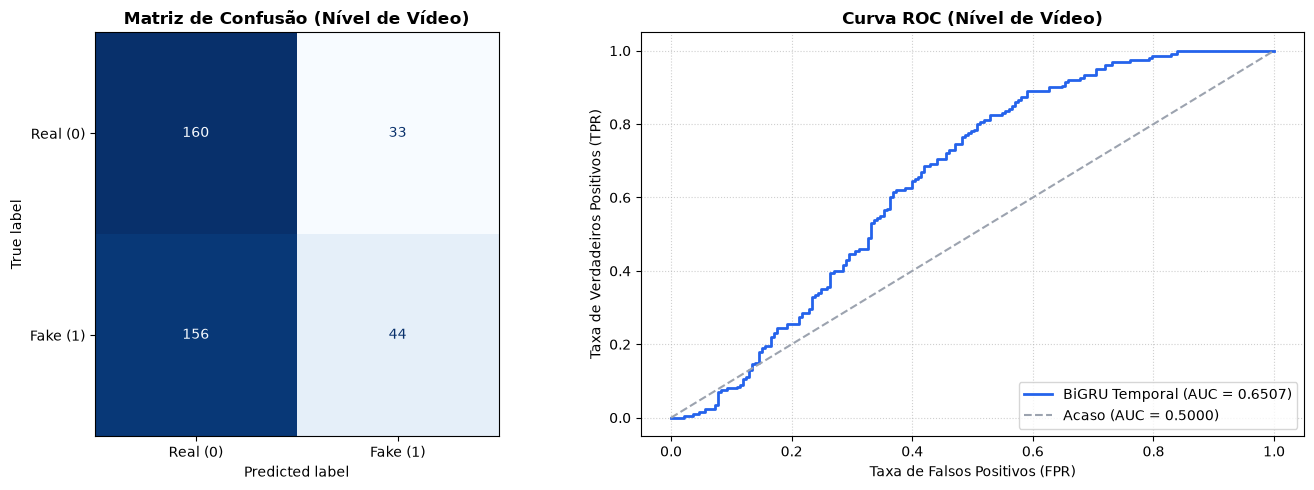

In [33]:
#@title Avaliação do dataset
temporal_model = tf.keras.models.load_model("best_temporal_model.keras")
frame_detector = m.DeepfakeDetector(
    "siglip2_base_patch16_224_original_backbone.keras", 
    "best_frame_model.keras"
)

true_labels_dict = {} 

test_temporal_results = evaluate_custom_dataset_temporal(
    temporal_model=temporal_model,
    detector_or_backbone=frame_detector,
    video_paths=video_paths,
    true_labels_dict=true_labels_dict,
    threshold=0.5
)

In [35]:
metrics_temporal = get_weighted_metrics(test_temporal_results)

display(print_weighted_metrics(metrics_temporal))



Métrica,Valor
Revocação (TPR),0.5191
Falsos Positivos (FPR),0.4701
Especificidade (TNR),0.5299
Taxa de Erro (ERR),0.4809
Acurácia Global (ACC),0.5191
F1-Score,0.4704
Coeficiente MCC,0.0617
Probabilidade de Falha (PMD),0.4809


In [ ]:
#@title Predição de um vídeo e plot das métricas
import random

# choose random video to predict and explain
# video_path = random.choice(video_paths)
video_path = "/dataset/Custom/manipulated/0005.mp4"
print(f"Video choosed for prediction: {video_path}")

frame_detector = m.DeepfakeDetector(backbone_path, "best_frame_model.keras")
detector = tf.keras.models.load_model("best_temporal_model.keras")

result = predict_and_explain_video(detector, video_path, CFG['pred_output_dir'], is_temporal=True,\
  frame_detector = frame_detector)

### 5.2 Modelo frame a frame

In [ ]:
#@title Avaliação do dataset

frame_detector = m.DeepfakeDetector(
    "siglip2_base_patch16_224_original_backbone.keras", 
    "best_frame_model.keras"
)

true_labels_dict = {} 

test_frame_results = evaluate_custom_dataset_frame_level(
    frame_model=frame_detector,
    video_paths=video_paths,
    aggregation="median",
    threshold=0.5
)

metrics_frame = get_weighted_metrics(test_frame_results)

display(print_weighted_metrics(metrics_frame))

In [ ]:
#@title Predição pra um vídeo ou mais, com explicação via GRADCAM
import random

# choose random video to predict and explain
# video_path = random.choice(video_paths)
video_path = "/dataset/Custom/manipulated/0005.mp4"
print(f"Video choosed for prediction: {video_path}")

detector = m.DeepfakeDetector(backbone_path, "best_frame_model.keras")
frame_detector = None

result = predict_and_explain_video(detector, video_path, CFG['pred_output_dir'])
plot_aggregation_comparison(result["frame_probs"])

## Resultado unificado

In [ ]:

metrics_frame = get_weighted_metrics(test_frame_results)
metrics_temporal = get_weighted_metrics(test_temporal_results)

results_comparison = {
    "Frame-Level (MLP)": metrics_frame,
    "BiGRU (Temporal)": metrics_temporal,
}

plot_metrics_graphic(
    results=results_comparison,
    metrics_to_plot=["TPR", "FPR", "TNR", "ERR", "ACC", "F1", "MCC"],
    title="comparacao_cross_domain_celebf_df"
)